In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import os
import zipfile
from pathlib import Path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shutil
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras import mixed_precision
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
set_seed(42)

pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", None)

In [ ]:
# 1. AKTIFKAN MIXED PRECISION
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Compute dtype: {policy.compute_dtype}")

# 2. SETUP MULTI-GPU STRATEGY
strategy = tf.distribute.MirroredStrategy()
num_gpus = strategy.num_replicas_in_sync
print(f'Jumlah GPU yang aktif: {num_gpus}')

Compute dtype: float16
Jumlah GPU yang aktif: 1


# Direktori

In [ ]:
BASE_DIR = os.getcwd()
with zipfile.ZipFile(os.path.join(BASE_DIR, 'drive', 'MyDrive', '2B.zip'), 'r') as zip_ref:
    zip_ref.extractall(os.path.join(BASE_DIR, 'data'))

FILE_PATH = Path(os.path.join(BASE_DIR, 'data', '2C', 'Cherry', 'data'))
image_paths = list(FILE_PATH.glob(r'**/*.jpg'))

# UTS DL NO 2B
- Nama    : Hans Richard Djojosantoso
- Nim     : 2802392942
- Dataset : B

Link Video : https://drive.google.com/file/d/1j1GvSqukYuJAN0ydgAke_DBb2444lqRA/view?usp=sharing

# A.Lakukan Exploratory Data Analysis

untuk memeriksa kondisi data yang anda miliki, seperti aspect ratio & resolution.

Lalu pisahkan data anda menjadi train, validation, dan test dengan proporsi 70:15:15! Lakukan pre-processing pada data anda.

## A.1.Folder and Count Check

In [ ]:
for root, dirs, files in os.walk(FILE_PATH):
    depth = root.replace(str(FILE_PATH), '').count(os.sep)
    if depth > 2:
        break
    indent  = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 1:
        jpgs = list(Path(root).glob('*.jpg'))
        print(f"  {indent} {len(jpgs)} .jpg")


all_images = list(FILE_PATH.glob('**/*.jpg')) + list(FILE_PATH.glob('**/*.png'))
print(f"\nTotal gambar : {len(all_images)}")

data/
  Cherry Normal leaf/
     376 .jpg
  Cherry_shot hole disease/
     264 .jpg
  Cherry Leaf Scorch/
     1097 .jpg
  Cherry purple leaf spot/
     987 .jpg
  Cherry brown_spot/
     614 .jpg

Total gambar : 3338


Terdapat perbedaan jumlah yang sangat kontras antar kelas:
- Kelas Mayoritas: Cherry Leaf Scorch (1097 gambar).
- Kelas Minoritas: Cherry shot hole disease (264 gambar).

## A.2.Image Metadata Check

In [ ]:
metadata = []

for img_path in image_paths:
    class_name = img_path.parent.name
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            aspect_ratio = width / height
            metadata.append({
                "Class": class_name,
                "Width": width,
                "Height": height,
                "Aspect_Ratio": aspect_ratio,
                "Path": img_path
            })
    except Exception as e:
        print(f"Error membaca file {img_path}: {e}")

df_eda = pd.DataFrame(metadata)
display(df_eda.groupby('Class').mean(numeric_only=True))

,Width,Height,Aspect_Ratio
Class,,,
Cherry Leaf Scorch,800.0,1000.0,0.8
Cherry Normal leaf,800.0,1000.0,0.8
Cherry brown_spot,800.0,1000.0,0.8
Cherry purple leaf spot,800.0,1000.0,0.8
Cherry_shot hole disease,800.0,1000.0,0.8


Berdasarkan table diatas, ditemukan bahwa dataset memiliki tingkat konsistensi yang sangat tinggi. Seluruh gambar pada kelima kelas memiliki resolusi seragam sebesar 800 x 1000 piksel dengan aspect ratio 0.8. Konsistensi ini menguntungkan karena meminimalisir bias ukuran pada model. Untuk menyesuaikan dengan input arsitektur AlexNet (224x224), akan dilakukan resizing global yang akan memberikan transformasi bentuk yang seragam pada seluruh sampel data.

## A.3.Contoh sample

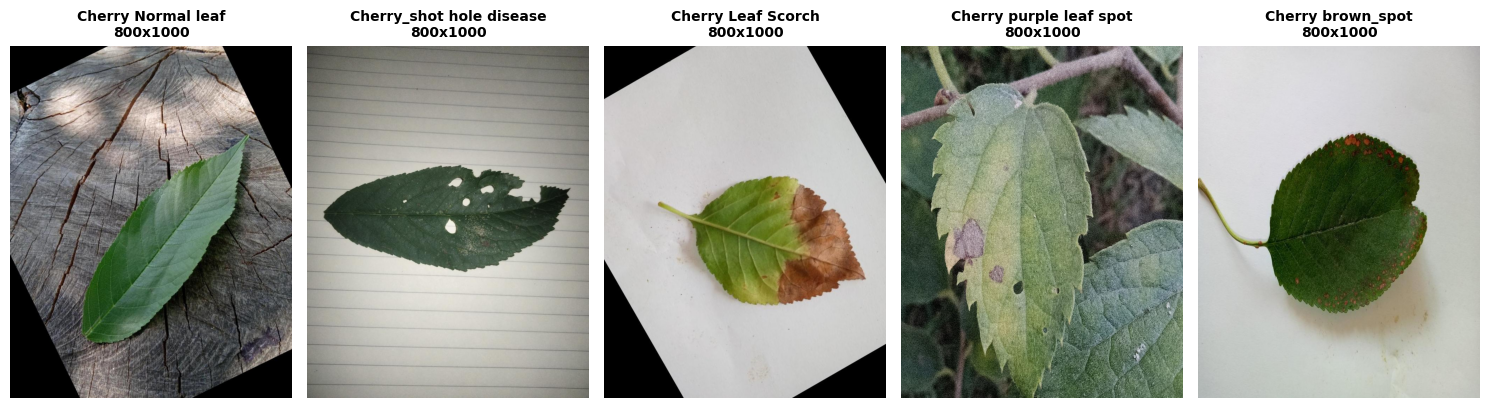

In [ ]:
classes = df_eda['Class'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(15, 4))

for ax, cls in zip(axes, classes):
    sample_path = random.choice(df_eda[df_eda['Class'] == cls]['Path'].tolist())
    img = Image.open(sample_path)

    ax.imshow(img)
    ax.set_title(f"{cls}\n{img.size[0]}x{img.size[1]}", fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## A.4.Color Intensity

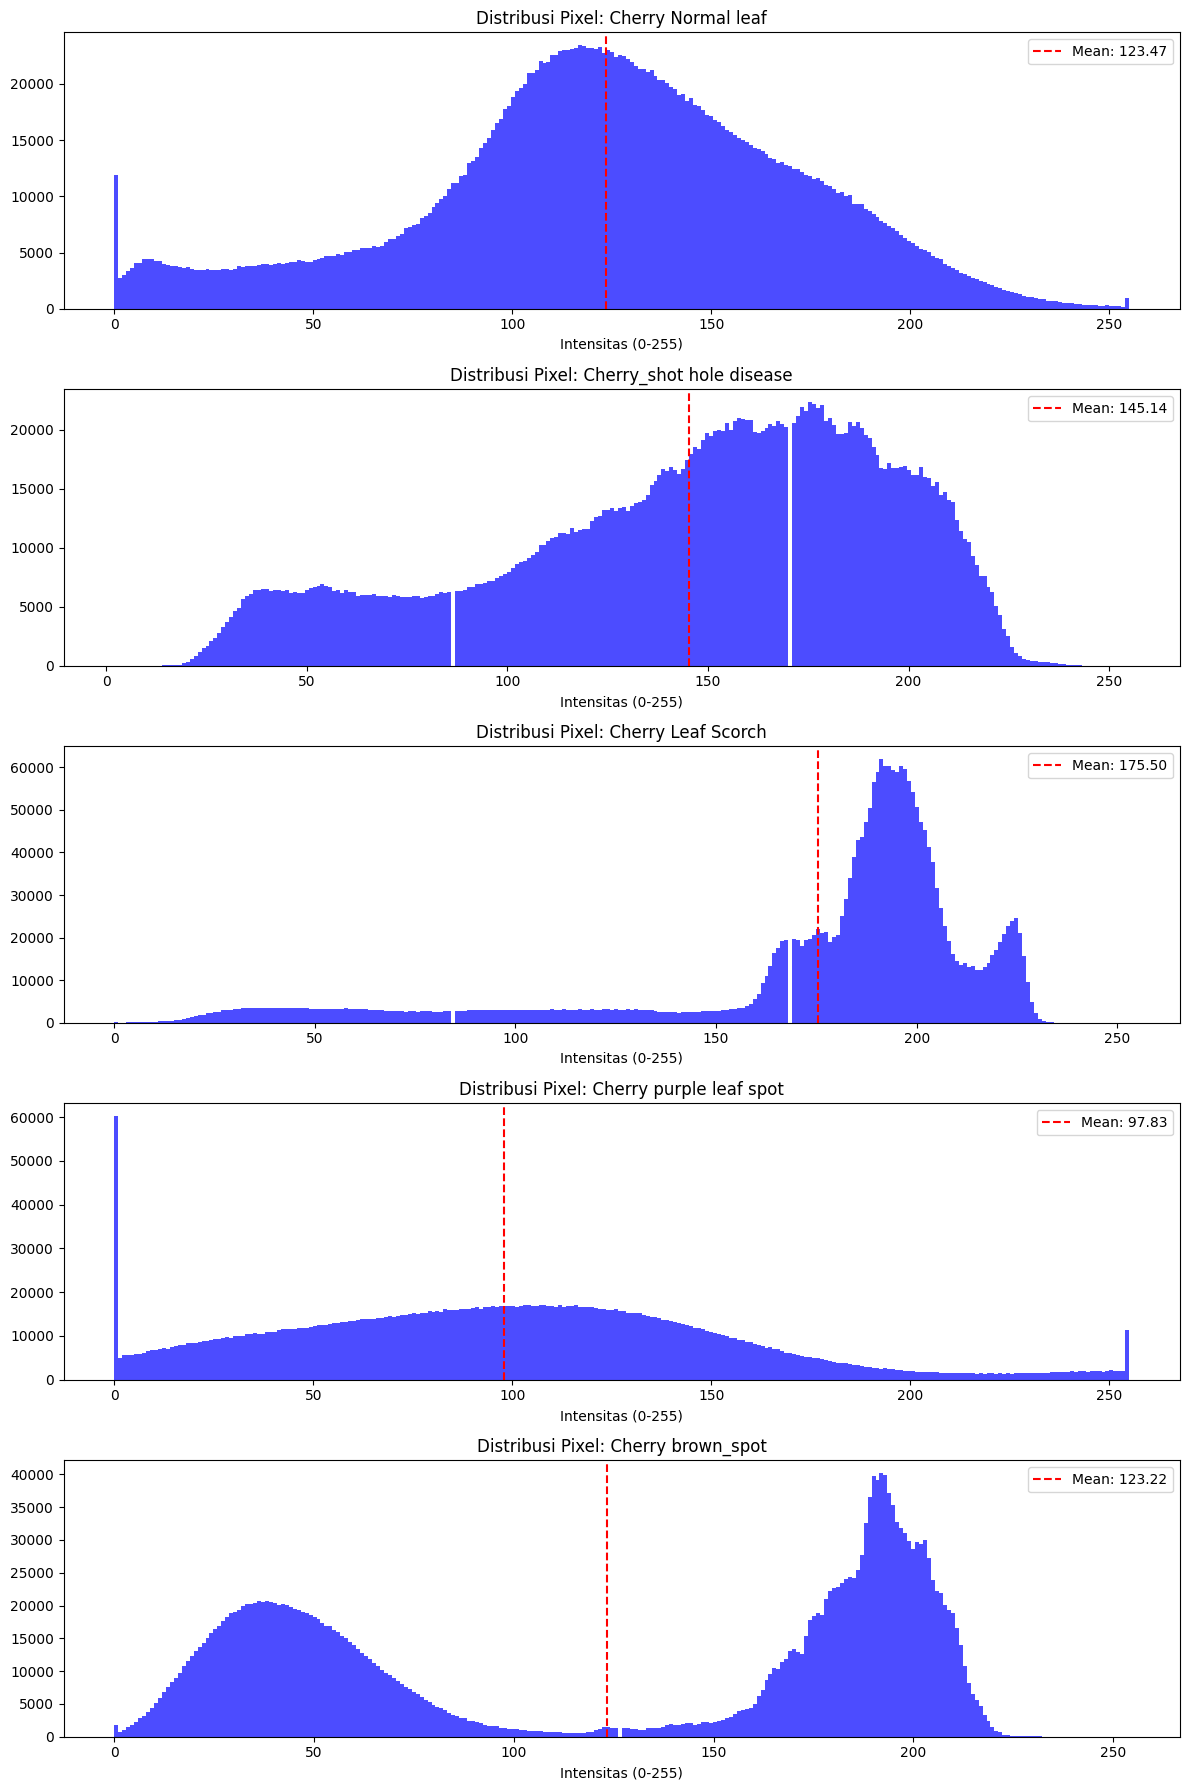

,Class,Shape,Max,Min,Mean
0,Cherry Normal leaf,1000x800x3,255,0,123.47
1,Cherry_shot hole disease,1000x800x3,255,2,145.14
2,Cherry Leaf Scorch,1000x800x3,253,0,175.50
3,Cherry purple leaf spot,1000x800x3,255,0,97.83
4,Cherry brown_spot,1000x800x3,254,0,123.22


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

intensity_stats = []
unique_classes = df_eda['Class'].unique()

plt.figure(figsize=(12, 18))

for i, cls in enumerate(unique_classes):
    sample_row = df_eda[df_eda['Class'] == cls].iloc[0]
    sample_path = sample_row['Path']

    try:
        img = Image.open(sample_path).convert('RGB')
        img_array = np.array(img)

        h, w, c = img_array.shape
        p_max = img_array.max()
        p_min = img_array.min()
        p_mean = img_array.mean()

        intensity_stats.append({
            "Class": cls,
            "Shape": f"{h}x{w}x{c}",
            "Max": p_max,
            "Min": p_min,
            "Mean": round(p_mean, 2)
        })

        plt.subplot(len(unique_classes), 1, i + 1)
        plt.hist(img_array.ravel(), bins=256, color='blue', alpha=0.7)
        plt.title(f"Distribusi Pixel: {cls}")
        plt.axvline(p_mean, color='red', linestyle='dashed', label=f'Mean: {p_mean:.2f}')
        plt.xlabel("Intensitas (0-255)")
        plt.legend()

    except Exception as e:
        print(f"Gagal memproses {cls}: {e}")

plt.tight_layout()
plt.show()

df_intensity_summary = pd.DataFrame(intensity_stats)
display(df_intensity_summary)

- Variasi Tingkat Kecerahan: Terdapat ketidakseimbangan pencahayaan yang signifikan antar kelas. Leaf Scorch sangat didominasi warna terang (Mean: 175.50), sementara Purple leaf spot sangat gelap (Mean: 97.83).

- Indikasi Artifact pada Gambar: Pada Purple leaf spot dan Normal leaf, terdapat garis lonjakan tajam persis di angka 0 (hitam pekat) dan beberapa di 255 (putih pekat). Ini mengindikasikan adanya background masking atau area kosong pada foto, bukan warna alami daun.

- Wajib melakukan Normalisasi: Perbedaan sebaran grafik ini adalah alasan teknis mengapa proses scaling (membagi nilai piksel dengan 255.0) wajib dilakukan. Tanpa normalisasi, model cenderung menebak kelas hanya berdasarkan seberapa terang/gelap gambarnya, bukan dari tekstur anatomi daunnya.

## A.B.Data Splitting (70:15:15)

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import os

src_root = Path(os.path.join(BASE_DIR, 'data', '2C', 'Cherry', 'data'))

out_root = Path(BASE_DIR) / 'drive' / 'MyDrive' / 'Binus' / 'Sem 4' / 'DL' / '2B' / 'dataset_final'

required_folder = ['train', 'val', 'test']
exists = all((out_root / sub).exists() for sub in required_folder)

if exists:
    print(f"Dataset sudah terbagi di: {out_root}")
else:
    print(f"Dataset belum ada maka split")

    if out_root.exists():
        shutil.rmtree(out_root)

    labels = [d for d in src_root.iterdir() if d.is_dir()]
    print(f"Memulai proses splitting untuk {len(labels)} kelas")

    for label_dir in labels:
        file_list = list(label_dir.glob('*.jpg'))
        class_name = label_dir.name

        train_data, remainder = train_test_split(
            file_list, test_size=0.30, random_state=42
        )
        val_data, test_data = train_test_split(
            remainder, test_size=0.50, random_state=42
        )

        splits = {
            'train': train_data,
            'val': val_data,
            'test': test_data
        }

        for folder_name, files in splits.items():
            target_path = out_root / folder_name / class_name
            target_path.mkdir(parents=True, exist_ok=True)

            for f in files:
                shutil.copy2(f, target_path / f.name)

    print(f"Data berhasil dipisah dan tersimpan di Drive: {out_root}")

Dataset sudah terbagi di: /content/drive/MyDrive/Binus/Sem 4/DL/2B/dataset_final


kode ini berfungsi untuk membagi (splitting) dataset gambar daun ceri secara otomatis menjadi tiga kelompok: Training (70%), Validation (15%), dan Testing (15%). Pertama, program akan mengecek apakah folder train, val, dan test sudah tersedia di Google Drive saya, kalo sudah, proses akan dihentikan agar tidak membuang waktu mengulang penyalinan data. Namun jika belum ada, program akan membersihkan folder tujuan, membaca seluruh gambar dari setiap kelas penyakit, lalu mengacak dan membaginya menggunakan fungsi train_test_split. Terakhir, file gambar tersebut disalin secara fisik ke dalam folder strukturnya masing-masing

In [ ]:
DATASET_PATH = str(out_root)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'val'),
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

#Optimisasi GPU
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

Found 2333 files belonging to 5 classes.
Found 501 files belonging to 5 classes.
Found 504 files belonging to 5 classes.


# B.Model CNN Alexnet

In [ ]:
with strategy.scope():
    model = models.Sequential([

        layers.Rescaling(1./255, input_shape = (224, 224, 3)),
        layers.Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4),
                      activation='relu', input_shape=(224, 224, 3), name='conv1'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool1'),

        layers.Conv2D(filters=256, kernel_size=(5, 5), padding='same',
                      activation='relu', name='conv2'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool2'),

        layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same',
                      activation='relu', name='conv3'),

        layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same',
                      activation='relu', name='conv4'),

        layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same',
                      activation='relu', name='conv5'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='pool3'),

        layers.Flatten(name='flatten'),

        layers.Dense(4096, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),

        layers.Dense(4096, activation='relu', name='dense2'),
        layers.Dropout(0.5, name='dropout2'),
        layers.Dense(5, activation='softmax', dtype='float32', name='output')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name = 'f1_score')],
        jit_compile=True
    )

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

history_baseline = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.4368 - f1_score: 0.2712 - loss: 1.3671 - val_accuracy: 0.5848 - val_f1_score: 0.3764 - val_loss: 1.1040
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.6481 - f1_score: 0.5222 - loss: 0.9028 - val_accuracy: 0.7445 - val_f1_score: 0.6879 - val_loss: 0.6813
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7694 - f1_score: 0.6942 - loss: 0.6000 - val_accuracy: 0.8084 - val_f1_score: 0.7214 - val_loss: 0.5359
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8324 - f1_score: 0.7733 - loss: 0.4471 - val_accuracy: 0.8443 - val_f1_score: 0.7887 - val_loss: 0.3611
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8641 - f1_score: 0.8111 - loss: 0.3753 - val_accuracy: 0.8323 - val_f1_score: 0.7860 - val_loss: 0.4670
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8774 - f1_score: 0.8279 - loss: 0.3238 - val_accuracy: 0.8523 - val_f1_score: 0.8182 - v

In [ ]:
import matplotlib.pyplot as plt

def plot_result(history):
    metrics = history.history
    epochs = range(1, len(metrics['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, metrics['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, metrics['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    ax1.set_title('Model Accuracy', fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(epochs, metrics['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    ax2.plot(epochs, metrics['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    ax2.set_title('Model Loss', fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

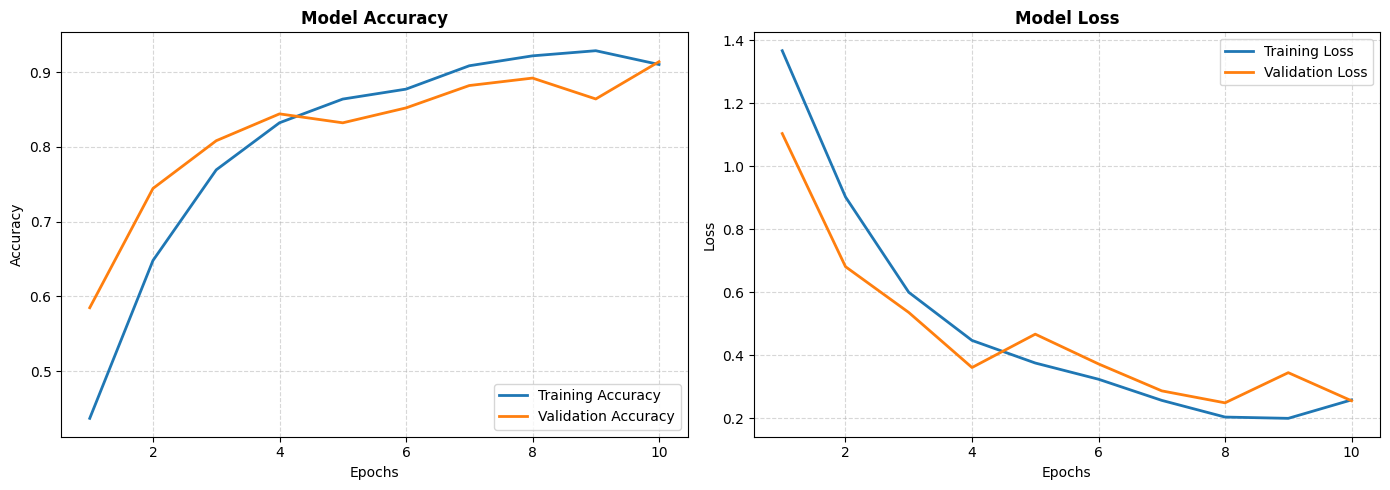

In [ ]:
plot_result(history_baseline)

Model mencapai akurasi 91% (Training) dan 91% (Validation), menunjukkan kemampuan pengenalan objek yang sangat baik dan konsisten. Penurunan Training Loss yang mulus membuktikan bahwa proses belajar berjalan stabil tanpa kendala gradien.

Validation Loss sempat menyentuh titik terendah di epoch 7 sebelum akhirnya tertahan di rentang 0.3 - 0.4. Model berhasil konvergen secara optimal. Terdapat indikasi overfitting ringan karena model mulai sedikit lebih pintar menghafal data latih dibandingkan data baru

# C. Modify Alexnet Arsitektur

Modifikasi arsitektur AlexNet yang sudah dibuat. Anda bisa
menambahkan DropOut, Batch Normalization, dan sebagainya atau melakukan fine-tuning untuk
hyperparameter pada model ini. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain
seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training
(minimal 10 epoch), serta analisis hasilnya.

In [ ]:
with strategy.scope():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    model_mod = models.Sequential([
        layers.RandomFlip("horizontal_and_vertical", input_shape=(224, 224, 3)),
        layers.RandomRotation(0.2),
        layers.Rescaling(1./127.5, offset=-1),
        base_model,
        layers.GlobalAveragePooling2D(name='global_avg_pooling'),
        layers.Dropout(0.3, name='dropout_regularization'),
        layers.Dense(5, activation='softmax', dtype='float32', name='predictions')
    ])

    model_mod.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')],
        jit_compile=True
    )

model_mod.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pooling              │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode = 'max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_mod = model_mod.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks = [early_stop, reduce_lr]
)

Epoch 1/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.3450 - f1_score: 0.2749 - loss: 1.5846 - val_accuracy: 0.4770 - val_f1_score: 0.3214 - val_loss: 1.2999 - learning_rate: 1.0000e-04
Epoch 2/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5392 - f1_score: 0.4546 - loss: 1.1734 - val_accuracy: 0.6727 - val_f1_score: 0.5297 - val_loss: 0.9656 - learning_rate: 1.0000e-04
Epoch 3/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6957 - f1_score: 0.6196 - loss: 0.8752 - val_accuracy: 0.7625 - val_f1_score: 0.6481 - val_loss: 0.7671 - learning_rate: 1.0000e-04
Epoch 4/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7707 - f1_score: 0.7079 - loss: 0.7004 - val_accuracy: 0.8263 - val_f1_score: 0.7411 - val_loss: 0.6409 - learning_rate: 1.0000e-04
Epoch 5/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8037 - f1_score: 0.7416 - loss: 0.6023 - val_accuracy: 0.8443 - val_f1_score: 0.7697 - val_loss: 0.5454 - learning_rate: 1.0000e-04
Epoch 6/40
73/

Modifikasi model MobileNetV2
- mengganti arsitektur dasar jadi MobileNetV2 dengan model pretrained ini, maka model sudah punya kemampuan untuk mendeteksi tepi, warna dantekstur daun
- Layer RandomFlip dan RandomNotation digunakan karena dalam baseline terdapat overfitting ringan sehingga diaugmentasi ringan untuk memanipulasi gambar secara acak di setiap epoch sehingga memaksa model belajar fitur esensial dari penyakit daun ceri, bukan sekedar hafal orientasi foto
- Mengubah nilai pixel input menggunakan layers.Rescaling(1./127.5, offset=-1). karena dalam MobileNetV2 butuh data dari rentang -1 sampai 1, sehingga memastikan data input kompatibel dengan standar pemrosesan pre-trained weights punya mobilenetv2
- menggunakan GlobalAveragePooling2D karena jauhg lebih efisien dibandingkan dengan flatten
- menggunakan dropout untuk mencegah model terlalu bergantung pada 1 pola spesifik
- menggunakan kombinasi ReduceLRonPlateau dan EarlyStopping dengan alokasi 40 epoch yg akan potong learning ratenya jadi 20 persennya dan pake Earlystopping jika model ga membaik selama 5 epoch maka akan di stop, dan menggunakan fitur restore best weight agar menyimpan bobot dari iterasi yg terbagus

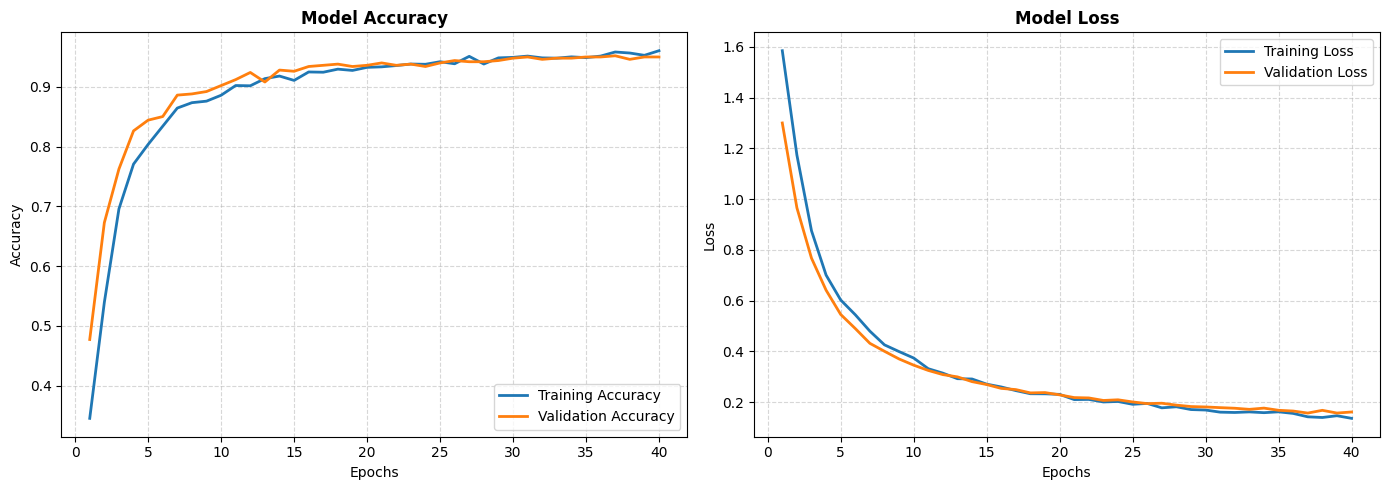

In [ ]:
plot_result(history_mod)

- Pada grafik Model Loss, kedua garis menurun secara landai, mulus, dan stabil dari epoch pertama hingga epoch 40, mendarat di angka loss yang sangat rendah (sekitar 0.1 - 0.2).
- dekatnya hasil akurasi dan validasi mengindikasikan model sangat baik dalam generalisasi dan tidak overfitting

Penerapan Transfer Learning menggunakan MobileNetV2 yang dipadukan dengan teknik regularisasi dan Learning Rate Scheduler berhasil mengatasi masalah ketidakstabilan dan indikasi overfitting pada baseline. Model akhir menunjukkan konvergensi yang mulus (Good Fit) dengan akurasi validasi mencapai ~95%, menjadikannya sangat handal untuk mendeteksi penyakit daun ceri pada data baru."

# D.Compare Model And Evaluating

In [ ]:
from sklearn.metrics import classification_report

test_dir = os.path.join(out_root, 'test')

test_data_eval = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=64,
    label_mode='categorical',
    shuffle=False
)

class_names = test_data_eval.class_names
y_true = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in test_data_eval])


y_pred_prob_base = model.predict(test_data_eval)
y_pred_base = np.argmax(y_pred_prob_base, axis=1)
print("Baseline")
print(classification_report(y_true, y_pred_base, target_names=class_names, digits=3))


y_pred_prob_mod = model_mod.predict(test_data_eval)
y_pred_mod = np.argmax(y_pred_prob_mod, axis=1)

print("MobileNetV2")
print(classification_report(y_true, y_pred_mod, target_names=class_names, digits=3))

Found 504 files belonging to 5 classes.


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 411ms/step
Baseline
                          precision    recall  f1-score   support

      Cherry Leaf Scorch      0.975     0.958     0.966       165
      Cherry Normal leaf      0.721     0.772     0.746        57
       Cherry brown_spot      0.767     0.957     0.852        93
 Cherry purple leaf spot      0.993     0.926     0.958       149
Cherry_shot hole disease      0.962     0.625     0.758        40

                accuracy                          0.901       504
               macro avg      0.884     0.848     0.856       504
            weighted avg      0.912     0.901     0.901       504



8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 499ms/step
MobileNetV2
                          precision    recall  f1-score   support

      Cherry Leaf Scorch      0.982     0.970     0.976       165
      Cherry Normal leaf      0.818     0.789     0.804        57
       Cherry brown_spot      0.947     0.957     0.952        93
 Cherry purple leaf spot      0.987     1.000     0.993       149
Cherry_shot hole disease      0.805     0.825     0.815        40

                accuracy                          0.944       504
               macro avg      0.908     0.908     0.908       504
            weighted avg      0.944     0.944     0.944       504



In [ ]:
report_base = classification_report(y_true, y_pred_base, output_dict=True)
report_mod = classification_report(y_true, y_pred_mod, output_dict=True)

data_evaluasi = {
    'Metrik Evaluasi': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],

    'AlexNet': [
        report_base['accuracy'],
        report_base['macro avg']['precision'],
        report_base['macro avg']['recall'],
        report_base['macro avg']['f1-score']
    ],

    'MobileNetV2': [
        report_mod['accuracy'],
        report_mod['macro avg']['precision'],
        report_mod['macro avg']['recall'],
        report_mod['macro avg']['f1-score']
    ]
}

df_eval = pd.DataFrame(data_evaluasi)

df_eval['Peningkatan'] = df_eval['MobileNetV2'] - df_eval['AlexNet']

for col in ['AlexNet', 'MobileNetV2']:
    df_eval[col] = df_eval[col].apply(lambda x: round(x, 3))

df_eval['Peningkatan'] = df_eval['Peningkatan'].apply(lambda x: f"+{x:.3f}" if x > 0 else f"{x:.3f}")

print("Perbandingan Performa Model Asli vs Modifikasi")
display(df_eval)

Perbandingan Performa Model Asli vs Modifikasi


,Metrik Evaluasi,AlexNet,MobileNetV2,Peningkatan
0,Accuracy,0.901,0.944,+0.044
1,Precision (Macro),0.884,0.908,+0.024
2,Recall (Macro),0.848,0.908,+0.061
3,F1-Score (Macro),0.856,0.908,+0.052


- Akurasi Global Naik (+4,4%): Tingkat keberhasilan prediksi keseluruhan meningkat dari 90,1% menjadi 94,4%. Model MobileNetV2 jauh lebih handal mengenali daun baru.

- Presisi Meningkat (+2,4%): Nilai presisi (Macro Avg) naik menjadi 90,8%, menunjukkan model baru lebih jarang salah menuduh daun sehat sebagai sakit (False Positive berkurang).

- Kepekaan Deteksi Meroket (+6,1%): Kenaikan terbesar ada pada nilai Recall (menjadi 90,8%). Model baru sangat peka dan meminimalisir kemungkinan daun sakit terlewat atau tidak terdeteksi (False Negative).

- Performa Lebih Adil (+5,2% F1-Score): Lonjakan Macro F1-Score menjadi 90,8% membuktikan MobileNetV2 berhasil mengatasi ketimpangan jumlah data. Model kini sama pintarnya dalam mendeteksi penyakit langka maupun penyakit umum.

Saran pengembangan:
- Fine-Tuning Lanjutan: Buka (unfreeze) beberapa layer terakhir MobileNetV2 dan latih ulang dengan learning rate yang sangat kecil. Ini membantu model beradaptasi lebih spesifik pada detail tekstur daun ceri untuk memaksimalkan akurasi.

- Atasi Ketimpangan Data: Gunakan metode Class Weights atau tambah augmentasi khusus pada kelas penyakit yang datanya sedikit (seperti shot hole). Ini akan memastikan model tidak bias dan makin akurat di kelas minoritas.